WE DO REGRESSION AND FIND NO. OF PASSENGERS DIED IN TITANIC INCIDENT

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd
import sklearn 
from matplotlib import style
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [90]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [91]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [92]:
train_df.describe(
)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [93]:
train_df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


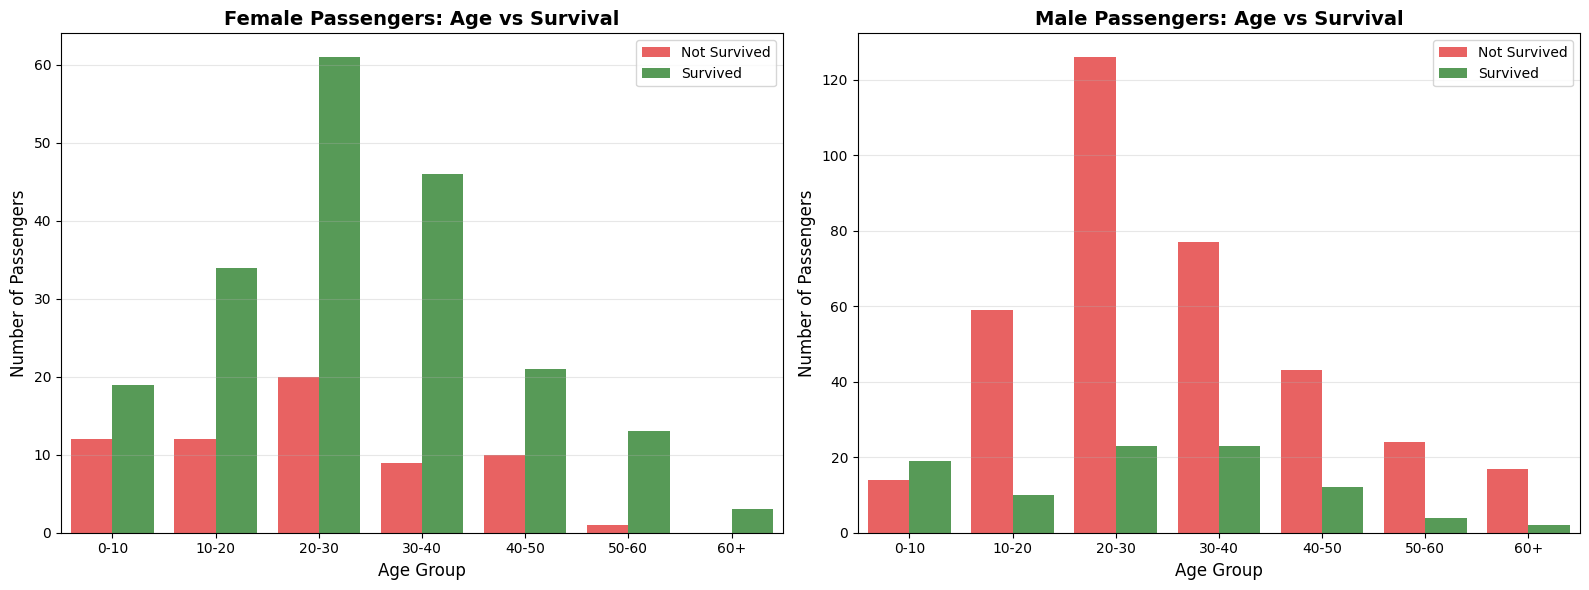


Female Survival by Age Group:
Survived    0   1
Age_Group        
0-10       12  19
10-20      12  34
20-30      20  61
30-40       9  46
40-50      10  21
50-60       1  13
60+         0   3


Male Survival by Age Group:
Survived     0   1
Age_Group         
0-10        14  19
10-20       59  10
20-30      126  23
30-40       77  23
40-50       43  12
50-60       24   4
60+         17   2


C:\Users\Vedant\AppData\Local\Temp\ipykernel_8324\347269147.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_survival = female_df.groupby(['Age_Group', 'Survived']).size().unstack(fill_value=0)
C:\Users\Vedant\AppData\Local\Temp\ipykernel_8324\347269147.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_survival = male_df.groupby(['Age_Group', 'Survived']).size().unstack(fill_value=0)


In [94]:
# Bar plot: Age vs Survival by Gender using Seaborn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create age bins
train_df['Age_Group'] = pd.cut(train_df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80], 
                                labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+'])

# Female: Age vs Survival
female_df = train_df[train_df['Sex'] == 'female'].copy()
sns.countplot(data=female_df, x='Age_Group', hue='Survived', palette={0: 'red', 1: 'green'}, 
              alpha=0.7, ax=axes[0])
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Number of Passengers', fontsize=12)
axes[0].set_title('Female Passengers: Age vs Survival', fontsize=14, fontweight='bold')
axes[0].legend(labels=['Not Survived', 'Survived'], loc='upper right')
axes[0].grid(True, alpha=0.3, axis='y')

# Male: Age vs Survival
male_df = train_df[train_df['Sex'] == 'male'].copy()
sns.countplot(data=male_df, x='Age_Group', hue='Survived', palette={0: 'red', 1: 'green'}, 
              alpha=0.7, ax=axes[1])
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Number of Passengers', fontsize=12)
axes[1].set_title('Male Passengers: Age vs Survival', fontsize=14, fontweight='bold')
axes[1].legend(labels=['Not Survived', 'Survived'], loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
female_survival = female_df.groupby(['Age_Group', 'Survived']).size().unstack(fill_value=0)
male_survival = male_df.groupby(['Age_Group', 'Survived']).size().unstack(fill_value=0)

print("\nFemale Survival by Age Group:")
print(female_survival)
print("\n\nMale Survival by Age Group:")
print(male_survival)

In [ ]:
train_df = train_df.dropna(subset=['Age'])


Before dropping NaN: (891, 13)
After dropping NaN: (714, 13)

NaN values in Age column: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,20-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,30-40
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,20-30
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,30-40
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,30-40


In [96]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  714 non-null    int64   
 1   Survived     714 non-null    int64   
 2   Pclass       714 non-null    int64   
 3   Name         714 non-null    object  
 4   Sex          714 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        714 non-null    int64   
 7   Parch        714 non-null    int64   
 8   Ticket       714 non-null    object  
 9   Fare         714 non-null    float64 
 10  Cabin        185 non-null    object  
 11  Embarked     712 non-null    object  
 12  Age_Group    714 non-null    category
dtypes: category(1), float64(2), int64(5), object(5)
memory usage: 73.6+ KB
